In [2]:
import pandas as pd
import matplotlib.pyplot as plt

hourly = pd.read_csv("data/saleshourly.csv")
daily = pd.read_csv("data/salesdaily.csv")
weekly = pd.read_csv("data/salesweekly.csv")
monthly = pd.read_csv("data/salesmonthly.csv")

1. Q: "What are the total sales quantities for each drug category (ATC code)?"

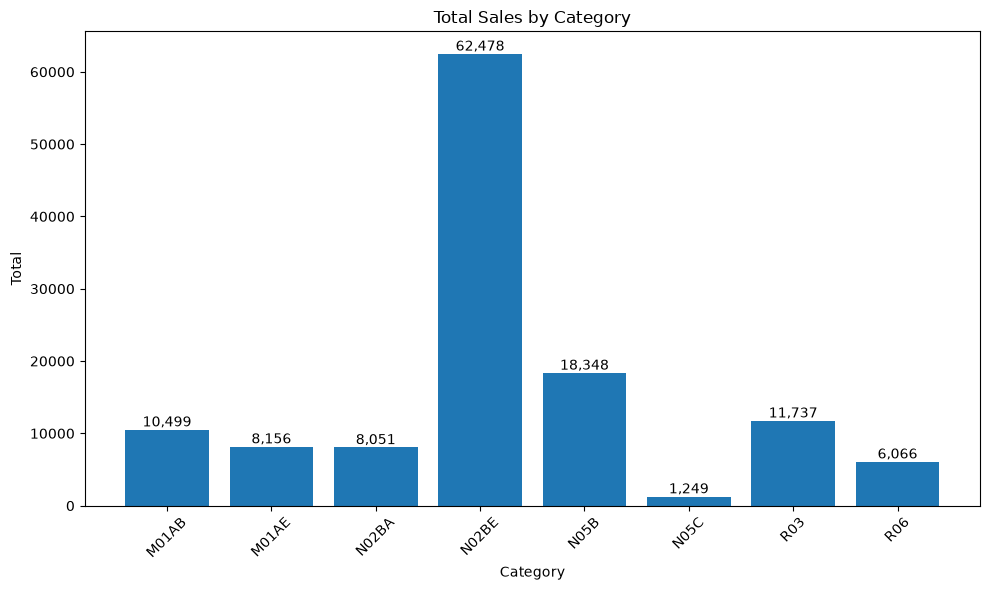

In [3]:
total_count = monthly[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']].sum()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(total_count.index, total_count.values)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center', va='bottom'
    )

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2. Q: "Which individual drug brands have the highest total sales?"
   A: ??? same question as 1? total highest sales the N02BE

3. Q: "Which three drugs have the highest sales in January 2015, July 2016, September 2017."

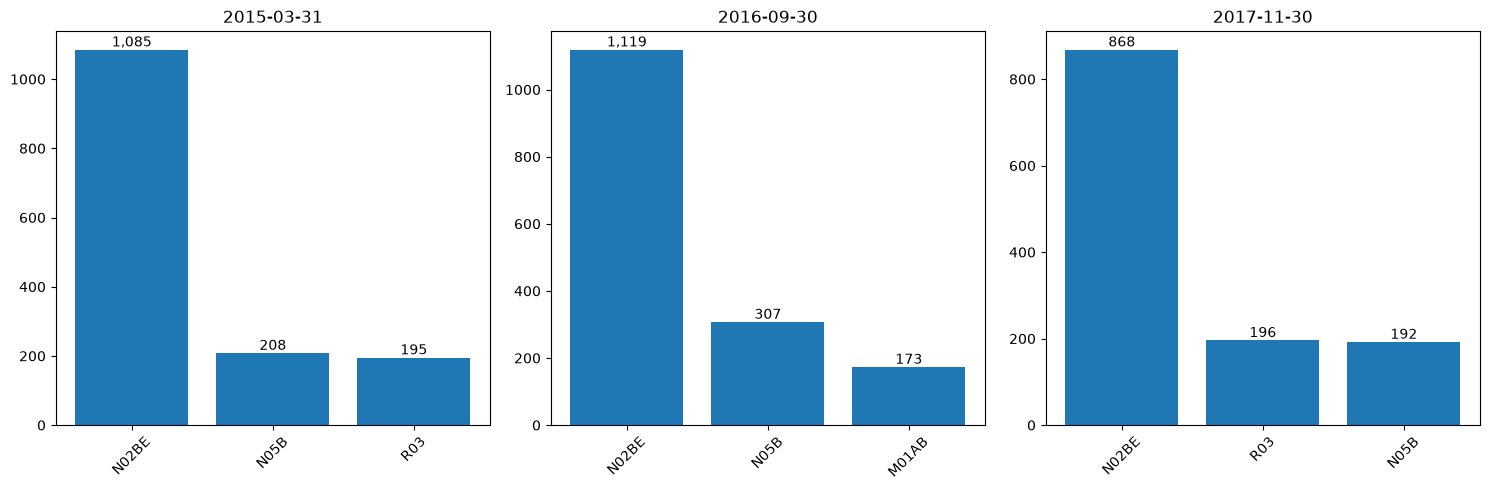

In [39]:
rows = [monthly.iloc[14], monthly.iloc[32], monthly.iloc[46]]

plot_rows = []

for row in rows:
    row = row.drop('datum')
    row = pd.to_numeric(row, errors='coerce')
    plot_rows.append(row)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, row, idx in zip(axes, plot_rows, [14, 32, 46]):
    top3 = row.nlargest(3)
    bars = ax.bar(top3.index, top3.values)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:,.0f}',
            ha="center", va="bottom"
        )

    ax.set_title(monthly.loc[idx, 'datum'])
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

4. Q: "Which drug has sold the most often in 2017?"

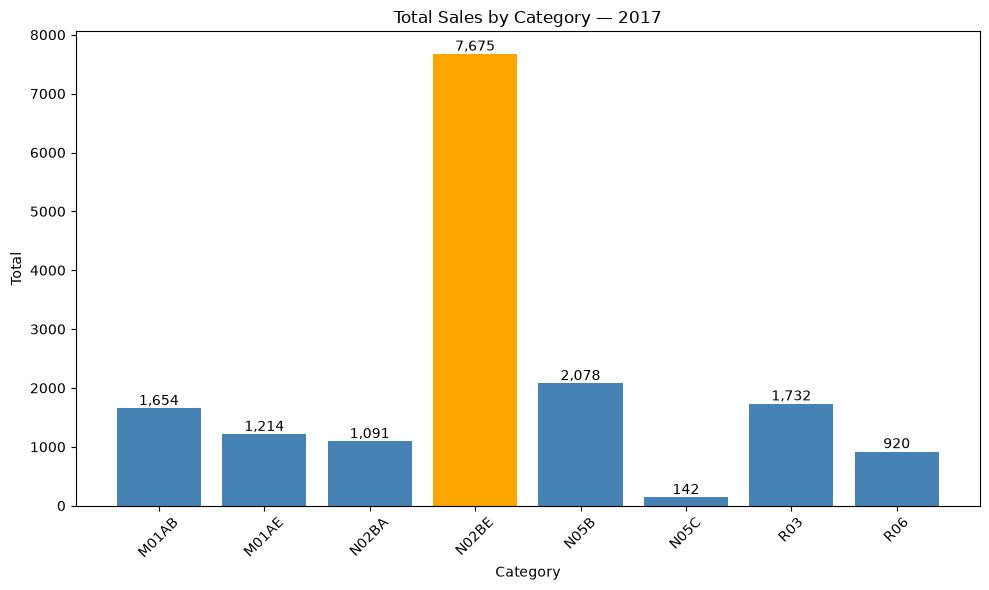

In [76]:
monthly['datum'] = pd.to_datetime(monthly['datum'])

filtered = monthly[monthly['datum'].dt.year == 2017]

total_for_2017 = filtered[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']].sum()
top_drug = total_for_2017.idxmax()
colors = ['orange' if cat == top_drug else 'steelblue' for cat in total_for_2017.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(total_for_2017.index, total_for_2017.values, color=colors)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center', va='bottom'
    )

ax.set_title('Total Sales by Category — 2017')
ax.set_xlabel('Category')
ax.set_ylabel('Total')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

5. Q: "Which drug category has the highest average daily sales?"

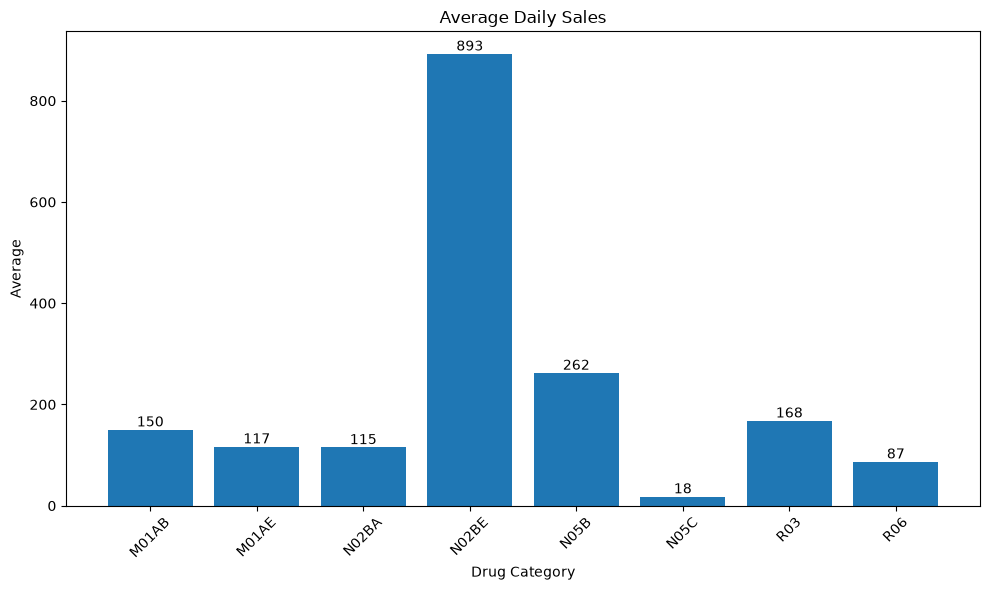

In [69]:
total_count = monthly[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']].mean()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(total_count.index, total_count.values)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center', va='bottom'
    )

plt.title('Average Daily Sales')
plt.xlabel('Drug Category')
plt.ylabel('Average')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

6. "Are respiratory drugs (R03) sold more during specific months?"

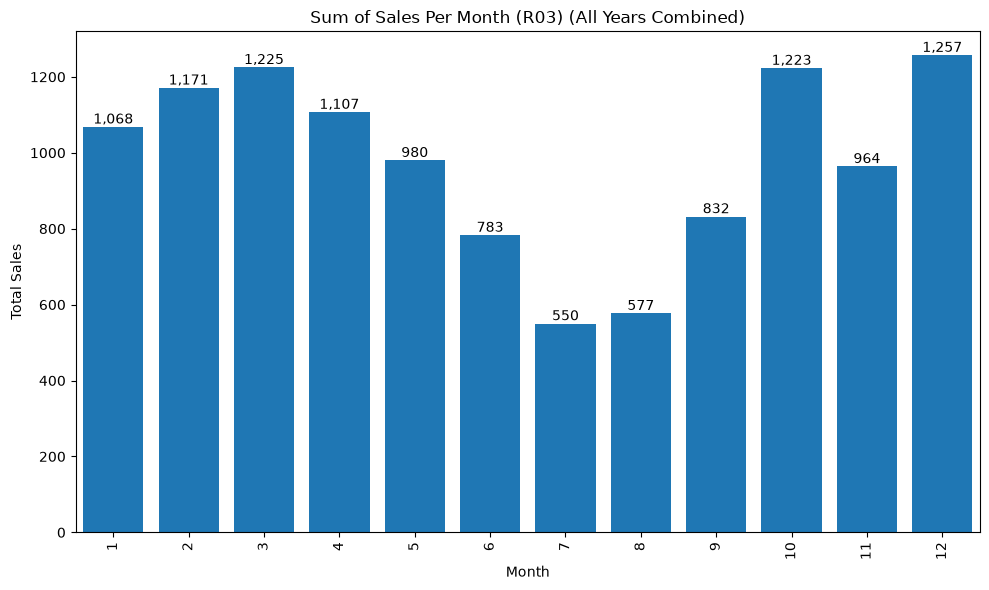

In [96]:
monthly['datum'] = pd.to_datetime(monthly['datum'])
monthly['month'] = monthly['datum'].dt.month

monthly_total = monthly.groupby('month')['R03'].sum()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(monthly_total.index.astype(str), monthly_total.values)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center', va='bottom'
    )

monthly_total.plot(kind='bar', figsize=(10, 6))
plt.title('Sum of Sales Per Month (R03) (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()